Model Evaluation & Choosing
the Right Model

Why Evaluation Matters

Training a model is easy. Knowing if it actually works is the hard part. A model that scores 98% on training data
might score 62% on new data. This gap is the real test of whether your model has learned a general pattern or just
memorised the training examples.

Building a Machine Learning model is only half the job.

The real question is:

"Will the model work well on new, unseen data?"

A model may achieve:

98% Training Accuracy
62% Test Accuracy

This means the model has memorized the training data instead of learning general patterns.

Therefore, evaluating a model correctly is essential before deploying it in the real world.

Types of Error

| Error Type           | What It Measures                | What It Tells You                                                      |
| -------------------- | ------------------------------- | ---------------------------------------------------------------------- |
| **Training Error**   | Error on training data          | Low error means the model learned the training data (or memorized it). |
| **Validation Error** | Error on validation data        | Helps detect overfitting and tune the model.                           |
| **Test Error**       | Error on completely unseen data | Best estimate of real-world performance.                               |


| Concept          | Key Idea                                                 |
| ---------------- | -------------------------------------------------------- |
| Training Error   | Measures performance on seen data                        |
| Validation Error | Helps tune and improve models                            |
| Test Error       | Estimates real-world performance                         |
| Overfitting      | Excellent training performance but poor test performance |
| Golden Rule      | Never repeatedly use the test set for model tuning       |


**The Golden Rule**

NEVER use your test set more than once. Every time you peek at test results and adjust your model, you're leaking
information. The final test score must come from data the model has NEVER influenced in any way

See Training Error vs Test Error Gap
Watch the gap grow as you increase model complexity:

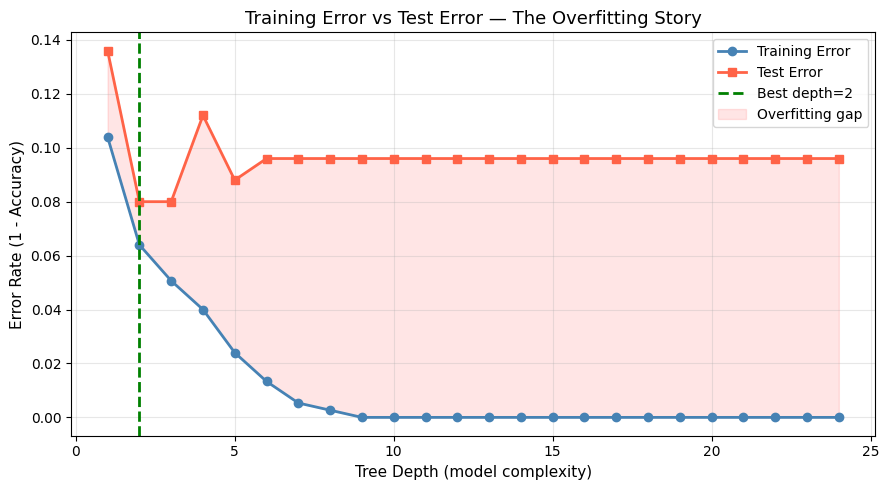

In [ ]:
# ■■ Training Error vs Test Error Gap ■■
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt, numpy as np



X, y = make_classification(
    n_samples=500,
    n_features=10,
    random_state=42)





X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42)

train_errs, test_errs = [], []

depths = range(1, 25)

for d in depths:

  tree = DecisionTreeClassifier(
      max_depth=d,
      random_state=42)


  tree.fit(X_train, y_train)

  train_errs.append(1 - accuracy_score(y_train, tree.predict(X_train)))
  test_errs.append(1 - accuracy_score(y_test, tree.predict(X_test)))


best = depths[test_errs.index(min(test_errs))]


plt.figure(figsize=(9, 5))
plt.plot(depths, train_errs, 'o-', lw=2, color='steelblue', label='Training Error')
plt.plot(depths, test_errs, 's-', lw=2, color='tomato', label='Test Error')
plt.axvline(x=best, color='green', lw=2, linestyle='--', label=f'Best depth={best}')
plt.fill_between(depths, train_errs, test_errs, alpha=0.1, color='red', label='Overfitting gap')
plt.xlabel('Tree Depth (model complexity)', fontsize=11)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=11)
plt.title('Training Error vs Test Error — The Overfitting Story', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
# STORY: As depth grows, train error → 0 (perfect memorisation)
# But test error has a minimum — that's the sweet spot

Cross-Validation

A single train/test split gives you ONE score — but what if that split was unlucky? Maybe all the hard examples landed
in your test set. K-Fold Cross-Validation solves this by using K different splits and averaging the scores.

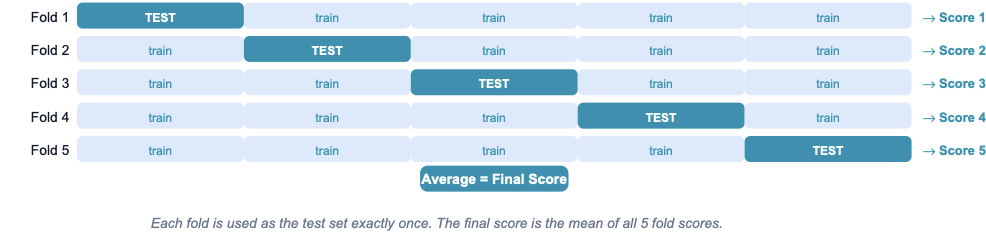

| K Value                      | Trade-Off                          | Recommended Use                                                     |
| ---------------------------- | ---------------------------------- | ------------------------------------------------------------------- |
| **K = 5**                    | Fast and reliable                  | Default choice; works well for most datasets                        |
| **K = 10**                   | More reliable but slower           | Preferred for smaller datasets (**< 1000 rows**)                    |
| **K = 3**                    | Very fast but slightly less stable | Large datasets (**> 100k rows**) where 5-fold CV becomes slow       |
| **K = N (Leave-One-Out CV)** | Most reliable but extremely slow   | Very small datasets (**< 100 rows**) where every sample is valuable |


**K-Fold Cross Validation Idea**

Instead of testing only once:

Divide data into K equal parts (folds)

Use one fold as the test set

Use remaining folds as training data

Repeat until every fold has been used as a test set

Average all scores

Cross-Validation Three Ways

From the simplest one-liner to full manual control:

In [ ]:
# ■■ Cross-Validation: One-liner + StratifiedKFold + Pipeline ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import (cross_val_score, KFold,
StratifiedKFold, cross_validate)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np



In [ ]:
X, y = make_classification(n_samples=600, n_features=10, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# ■■ Method 1: Simplest one-liner ■■
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Scores: {scores.round(3)}')
print(f'Mean: {scores.mean():.3f} Std: {scores.std():.3f}')
print(f'Reliable range: {scores.mean()-2*scores.std():.3f} – {scores.mean()+2*scores.std():.3f}')

5-Fold CV Scores: [0.858 0.933 0.908 0.9   0.942]
Mean: 0.908 Std: 0.029
Reliable range: 0.850 – 0.967


In [ ]:
# ■■ Method 2: StratifiedKFold (keeps class ratio in each fold) ■■
# Use this for classification, especially with imbalanced classes
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
print(f'\nStratified 5-Fold F1: {strat_scores.mean():.3f} ± {strat_scores.std():.3f}')


Stratified 5-Fold F1: 0.908 ± 0.027


In [ ]:
# ■■ Method 3: cross_validate — get multiple metrics at once ■■
results = cross_validate(model, X, y, cv=5,
scoring=['accuracy','f1_macro','roc_auc'],
    return_train_score=True)
print('\ncross_validate results:')
for metric in ['accuracy','f1_macro','roc_auc']:
  train_k = f'train_{metric}'
  test_k = f'test_{metric}'
  print(f' {metric:12s}: train={results[train_k].mean():.3f} test={results[test_k].mean():.3f}')


cross_validate results:
 accuracy    : train=1.000 test=0.908
 f1_macro    : train=1.000 test=0.908
 roc_auc     : train=1.000 test=0.970


In [ ]:
# ■■ Method 4: Pipeline + CV (scale inside CV — no data leakage!) ■■
pipe = Pipeline([
('scaler', StandardScaler()), # Scale inside each fold
('model', LogisticRegression(max_iter=1000))
])
pipe_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'\nPipeline CV (no leakage): {pipe_scores.mean():.3f} ± {pipe_scores.std():.3f}')


Pipeline CV (no leakage): 0.915 ± 0.030


Comparing Multiple Models

There is no single best algorithm for every problem. The right approach is to train several models, evaluate them on the
same data with the same metric, and choose based on performance, speed, and interpretability needs.

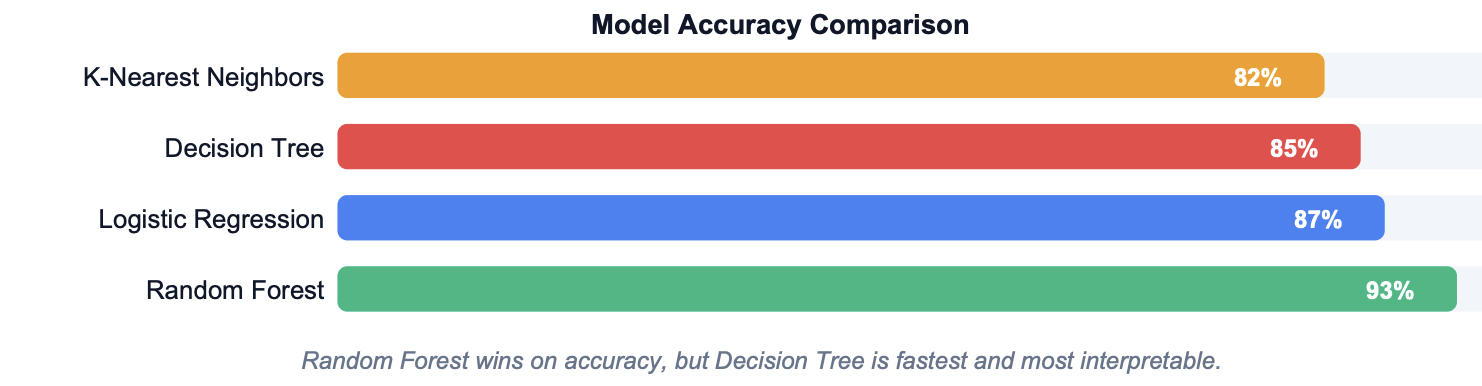

| Model                            | Best For                                                                 | Avoid When                                                         | Typical Accuracy           |
| -------------------------------- | ------------------------------------------------------------------------ | ------------------------------------------------------------------ | -------------------------- |
| **Logistic Regression**          | Linearly separable data, binary classification, probability prediction   | Data contains complex non-linear relationships                     | **Good Baseline** (75–85%) |
| **Decision Tree**                | Need easy interpretation, rule-based decisions, mixed feature types      | Large datasets where overfitting is likely                         | **Medium** (78–88%)        |
| **Random Forest**                | General-purpose classification, high accuracy, robust predictions        | Very large datasets where training time and memory become concerns | **High** (85–95%)          |
| **K-Nearest Neighbors (KNN)**    | Small datasets, similarity-based problems, simple classification tasks   | High-dimensional data or very large datasets                       | **Medium** (75–88%)        |


Build a Model Leaderboard with One Loop

Train 5 models on the same data, collect metrics, build a comparison DataFrame:

In [ ]:
# ■■ Model Comparison Leaderboard ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
X, y = make_classification(n_samples=800, n_features=15, random_state=42)

In [ ]:
# ■■ Define models (wrapped in Pipeline to include scaling) ■■
models = {
'Logistic Regression' : Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN (k=5)' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=5))])
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():


    cv_res = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'f1_macro', 'roc_auc'],
        return_train_score=False
    )



    results.append({
        'Model': name,
        'Accuracy': cv_res['test_accuracy'].mean(),
        'F1 Score': cv_res['test_f1_macro'].mean(),
        'AUC-ROC': cv_res['test_roc_auc'].mean(),
        'CV Std': cv_res['test_accuracy'].std(),

    })

    print(
        f'{name:22s}: '
        f'Acc={results[-1]["Accuracy"]:.3f} '
        f'F1={results[-1]["F1 Score"]:.3f} '
        f'AUC={results[-1]["AUC-ROC"]:.3f} '

    )

Logistic Regression   : Acc=0.930 F1=0.930 AUC=0.975 
Decision Tree         : Acc=0.925 F1=0.925 AUC=0.948 
Random Forest         : Acc=0.936 F1=0.936 AUC=0.977 
KNN (k=5)             : Acc=0.886 F1=0.886 AUC=0.949 


In [ ]:
# ■■ Build the leaderboard ■■
df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']] = df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']].round(4)
print('\n' + '='*70)
print('MODEL LEADERBOARD')
print('='*70)
print(df_res.to_string(index=False))


MODEL LEADERBOARD
              Model  Accuracy  F1 Score  AUC-ROC  CV Std
      Random Forest    0.9362    0.9362   0.9775  0.0310
Logistic Regression    0.9300    0.9300   0.9752  0.0222
      Decision Tree    0.9250    0.9249   0.9481  0.0265
          KNN (k=5)    0.8863    0.8860   0.9487  0.0242


Hyperparameter Tuning — GridSearchCV

Hyperparameters are settings you choose before training starts — things like max_depth, n_estimators,
learning_rate. The model cannot learn these from data; you must set them. GridSearchCV automates the search by
trying every combination.

Parameters vs Hyperparameters

| Feature                           | Parameters                                                                                            | Hyperparameters                                                      |
| --------------------------------- | ----------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------- |
| **What are they?**                | Values learned automatically from the training data                                                   | Settings chosen before training begins                               |
| **Who decides them?**             | The machine learning algorithm learns them                                                            | The data scientist or ML engineer sets them                          |
| **Examples**                      | Weights in Logistic Regression, Split Thresholds in Decision Trees, Coefficients in Linear Regression | `max_depth`, `n_estimators`, `learning_rate`, `K` in KNN, `C` in SVM |
| **How are they set?**             | Automatically learned during training                                                                 | Manually or using GridSearchCV / RandomizedSearchCV                  |
| **Changed During Training?**      |  Yes, continuously updated while learning                                                            |  No, fixed before `.fit()` is called                                |
| **Purpose**                       | Help the model learn patterns from data                                                               | Control how the learning process happens                             |
| **Can We Directly Control Them?** | Usually No                                                                                            | Yes                                                                  |


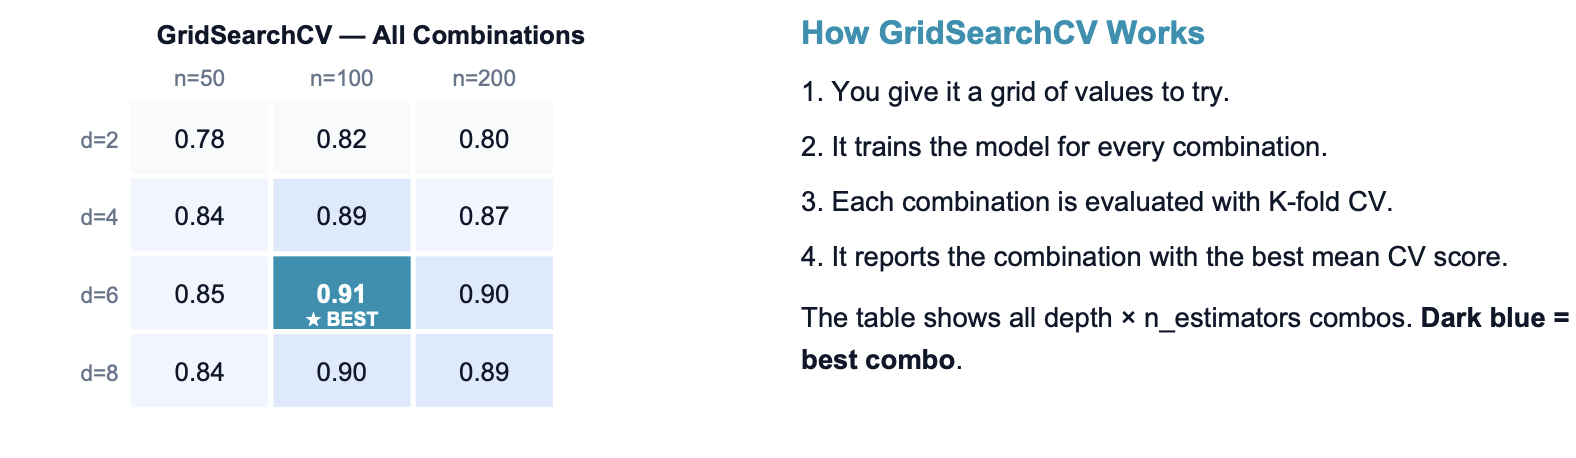

GridSearchCV + RandomizedSearchCV

Grid search tries everything; random search is faster for large grids:

In [ ]:
# ■■ GridSearchCV
from sklearn.model_selection import GridSearchCV  StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
import pandas as pd, numpy as np
X, y = make_classification(n_samples=600, n_features=12, random_state=42)

In [ ]:
# ■■ Part 1: GridSearchCV for Decision Tree ■■
# Hyperparameters to test
param_grid = {
    'max_depth': [2, 4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy']
}

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',

)

# Train and find best combination
grid_search.fit(X, y)

# Results
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Accuracy: 0.9083


In [ ]:
# Show GridSearch results
results = pd.DataFrame(grid_search.cv_results_)

# Top 5 models
top_5 = results[
    ['param_max_depth', 'param_criterion',
     'mean_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(5)

print("\nTop 5 Models:")
print(top_5)


Top 5 Models:
   param_max_depth param_criterion  mean_test_score  rank_test_score
61               4         entropy         0.908333                1
62               4         entropy         0.908333                1
60               4         entropy         0.908333                1
0                2            gini         0.903333                4
4                2            gini         0.903333                4


LAB : MODEL COMPARISION DASHBOARD

Build a complete model selection pipeline: load data, preprocess, train 4 models, evaluate with cross-validation, tune
hyperparameters, and produce a final comparison report. We use the Pima Indians Diabetes dataset as the
benchmark.

Step 1 — Load, Clean, Split

In [ ]:
# ■■ Load and Clean ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time, warnings; warnings.filterwarnings('ignore')

# Check if 'diabetes.csv' exists, if not, download it
import os
if not os.path.exists('diabetes.csv'):
    # Using wget to download the file from a common public repository
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
  df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')
# Output: {0: 500, 1: 268} — slightly imbalanced

--2026-06-05 01:28:22--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0s      

2026-06-05 01:28:22 (81.2 MB/s) - ‘diabetes.csv’ saved [23873/23873]

Dataset: 768 rows, 8 features
Class balance: {0: 500, 1: 268}


Step 2 — Build Models & Run Cross-Validation

In [ ]:
# ■■ Cross-Validation Leaderboard ■■
# Models — LR and KNN need scaling; trees don't (Pipeline handles this cleanly)
models = {
    'Logistic Regression': Pipeline([('sc',StandardScaler()),
('m',LogisticRegression(max_iter=1000,random_state=42))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN' : Pipeline([('sc',StandardScaler()),
('m',KNeighborsClassifier(n_neighbors=7))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['accuracy','f1_macro','roc_auc','precision_macro','recall_macro']
records = []
for name, model in models.items():
  t0 = time.time()
  res = cross_validate(model, X, y, cv=cv, scoring=metrics)
  elapsed = time.time()-t0
  row = {'Model': name, 'Time(s)': round(elapsed,2)}
  for m in metrics:
    row[m.replace('_macro','').title()] = round(res[f'test_{m}'].mean(), 4)
    row[f'{m.replace('_macro','').title()}_std'] = round(res[f'test_{m}'].std(), 4)
  records.append(row)
leaderboard = pd.DataFrame(records).sort_values('Accuracy', ascending=False)
print(leaderboard[['Model','Accuracy','F1','Roc_Auc','Precision','Recall','Time(s)']].to_string(index=False))

              Model  Accuracy     F1  Roc_Auc  Precision  Recall  Time(s)
Logistic Regression    0.7708 0.7320   0.8372     0.7602  0.7219     0.19
      Random Forest    0.7577 0.7236   0.8235     0.7367  0.7170     2.78
                KNN    0.7435 0.7026   0.7912     0.7206  0.6948     0.14
      Decision Tree    0.7082 0.6682   0.7516     0.6851  0.6719     0.12


Step 3 — Tune the Best Model with GridSearchCV

In [ ]:
# ■■ GridSearch Tuning ■■
# From the leaderboard, suppose Random Forest wins
# Tune its key hyperparameters
param_grid = {
    'n_estimators' : [50, 100, 200],
'max_depth' : [None, 5, 10],
'min_samples_leaf': [1, 3, 5],
}
# 3×3×3 = 27 combos × 5-fold = 135 fits — runs in ~1 minute
gs = GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid, cv=cv, scoring='accuracy',
n_jobs=-1, verbose=0
)
gs.fit(X, y)
print(f'Best params : {gs.best_params_}')
print(f'Best CV acc : {gs.best_score_:.4f}')
# Compare tuned vs default
default_rf = RandomForestClassifier(n_estimators=100, random_state=42)
default_scores = cross_val_score(default_rf, X, y, cv=cv, scoring='accuracy')
tuned_scores = cross_val_score(gs.best_estimator_, X, y, cv=cv, scoring='accuracy')
print(f'\nDefault RF accuracy: {default_scores.mean():.4f} ± {default_scores.std():.4f}')
print(f'Tuned RF accuracy: {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}')

Best params : {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 50}
Best CV acc : 0.7759

Default RF accuracy: 0.7577 ± 0.0266
Tuned RF accuracy: 0.7759 ± 0.0367


Step 4 — Final Evaluation + Confusion Matrix Dashboard

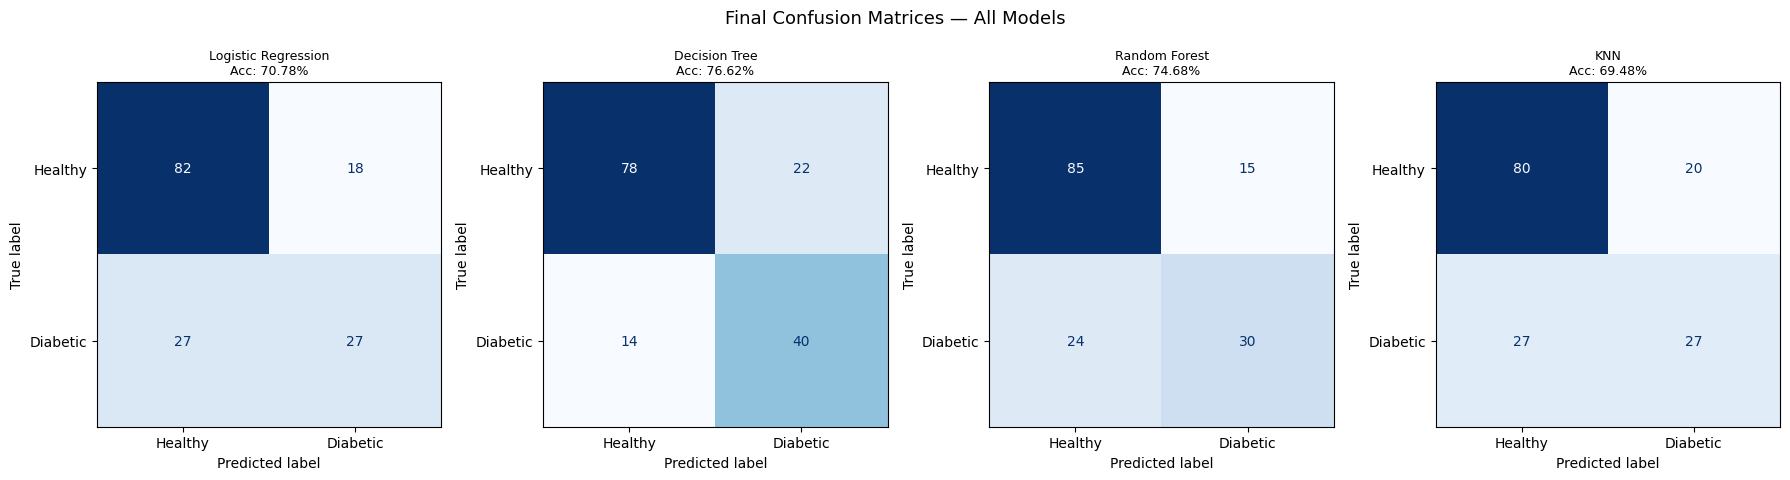


=== FINAL REPORT: Random Forest (Tuned) ===
              precision    recall  f1-score   support

     Healthy       0.78      0.85      0.81       100
    Diabetic       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [ ]:
# ■■ Final Evaluation Dashboard ■■
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# One final hold-out test — we only do this ONCE
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
Final_models = {
'Logistic Regression': Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : gs.best_estimator_, # Tuned version
'KNN' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=7))]),
}
final_results = []
for ax, (name, model) in zip(axes, Final_models.items()):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(
  ax=ax, cmap='Blues', colorbar=False)
  ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=9)
  final_results.append({'Model':name, 'Test Accuracy':f'{acc:.2%}'})
plt.suptitle('Final Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
# Final report for best model
best_model = Final_models['Random Forest']
print('\n=== FINAL REPORT: Random Forest (Tuned) ===')
print(classification_report(y_test, best_model.predict(X_test),
target_names=['Healthy','Diabetic']))

Machine Learning Evaluation & Model Selection – Quick Cheat Sheet

| Concept                         | Key Code / Function                                            | Remember                                                                    |
| ------------------------------- | -------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **K-Means Clustering**          | `KMeans(n_clusters=K, n_init=10)`                              | Always apply **StandardScaler** before K-Means                              |
| **Elbow Method**                | `km.inertia_` for K in `range(2,11)`                           | Look for the **bend (elbow)** where improvements become small               |
| **Silhouette Score**            | `silhouette_score(X, labels)`                                  | Range: **0 to 1** → Higher = Better clustering                              |
| **Cluster Visualisation**       | `plt.scatter(X[:,0], X[:,1], c=labels)`                        | Color points by cluster, mark centroids with **X**                          |
| **Correlation Matrix**          | `df.corr()`                                                    | Shows feature relationships; often visualized as a heatmap                  |
| **Correlation Heatmap**         | `sns.heatmap(df.corr(), annot=True)`                           | Strong positive = high positive value, strong negative = low negative value |
| **Outlier Detection (IQR)**     | `Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`                                 | Detect outliers using lower and upper fences                                |
| **Outlier Capping**             | `df[col].clip(lower, upper)`                                   | Winsorizing — reduce outlier impact                                         |
| **Outlier Removal**             | `df[(df[col]>=lower)&(df[col]<=upper)]`                        | Remove extreme values if they are errors                                    |
| **Training vs Test Error**      | `model.score(X_train,y_train)`<br>`model.score(X_test,y_test)` | Large gap = Overfitting                                                     |
| **Cross Validation**            | `cross_val_score(model,X,y,cv=5)`                              | More reliable than a single train-test split                                |
| **Stratified Cross Validation** | `StratifiedKFold(n_splits=5)`                                  | Maintain class balance in classification tasks                              |
| **Multiple Metrics**            | `cross_validate(model,X,y,scoring=[...])`                      | Evaluate Accuracy, Precision, Recall, F1, AUC together                      |
| **Pipeline**                    | `Pipeline([('sc',Scaler()),('m',Model())])`                    | Prevents data leakage and simplifies workflow                               |
| **Model Comparison**            | Loop + `cross_validate()` + DataFrame                          | Compare models using Accuracy, F1, AUC, Std Dev                             |
| **GridSearchCV**                | `GridSearchCV(model,param_grid,cv=5)`                          | Exhaustive search over all parameter combinations                           |
| **RandomizedSearchCV**          | `                                                              |                                                                             |
